In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df = pd.read_csv('retail_store_inventory.csv')


print(df.shape)  


(73100, 15)


In [2]:
df.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [4]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [5]:
print(df.isnull().sum())

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [6]:
df.nunique()

Date                    731
Store ID                  5
Product ID               20
Category                  5
Region                    4
Inventory Level         451
Units Sold              498
Units Ordered           181
Demand Forecast       31608
Price                  8999
Discount                  5
Weather Condition         4
Holiday/Promotion         2
Competitor Pricing     9751
Seasonality               4
dtype: int64

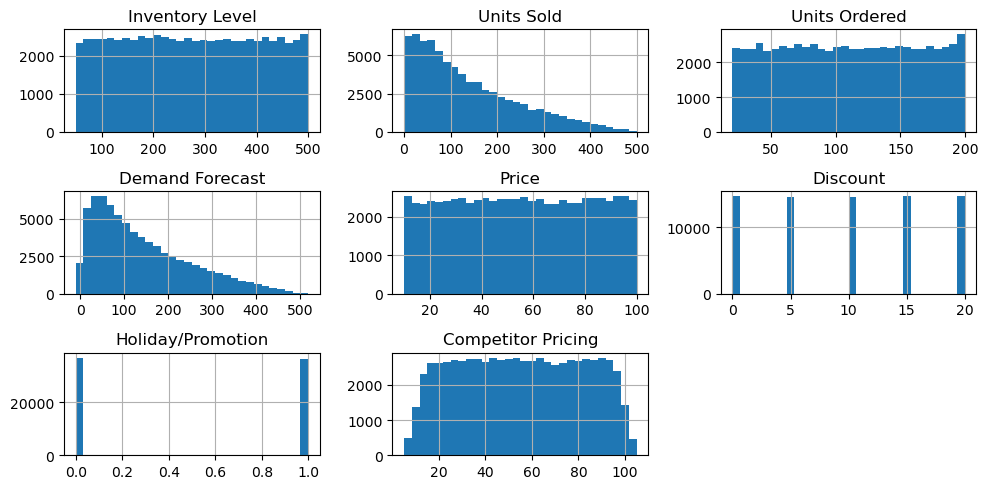

In [7]:
df.hist(bins=30, figsize=(10, 5))
plt.tight_layout()
plt.show()

Key Findings:

Inventory Level, Units Ordered, Price:
Distributions are fairly uniform, indicating these features are spread evenly across their ranges.

Units Sold, Demand Forecast:
Strong right-skew (most values are low with a long tail), meaning low sales and forecast volumes are far more common than high ones.

Discount:
Highly discrete; only a few specific discount levels (e.g., 0%, 5%, 10%, 15%, 20%) are used.

Holiday/Promotion:
Binary distribution (0 or 1), nearly evenly split between promotional and non-promotional periods.

Competitor Pricing:
Bell-shaped (normal-like), centered around mid-range prices with fewer very low or very high competitor prices.

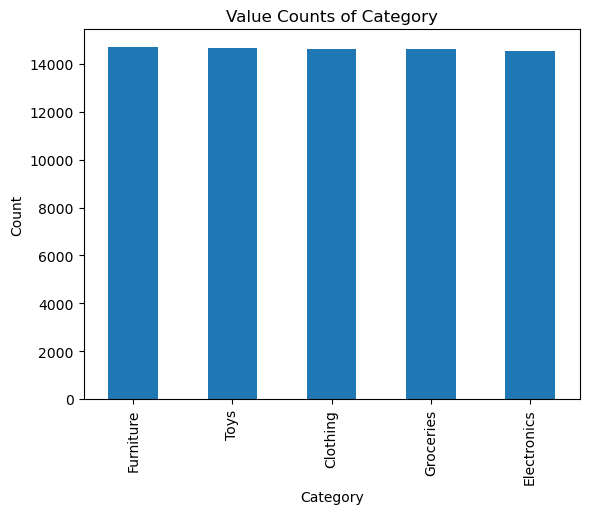

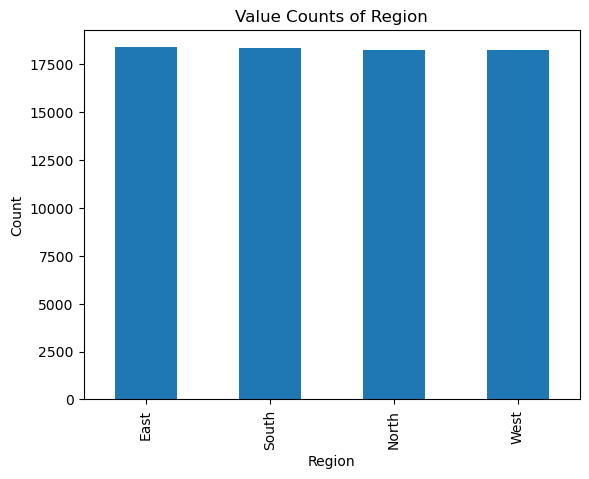

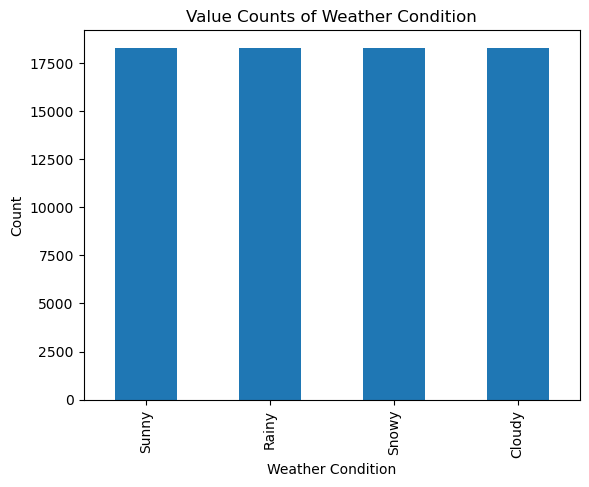

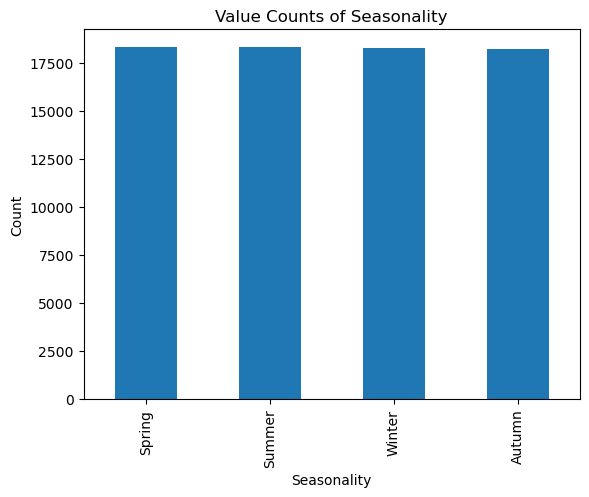

In [8]:
categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality']

for col in categorical_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Value Counts of {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


Category:
Product categories (Furniture, Toys, Clothing, Groceries, Electronics) are evenly distributed — no single category dominates.

Region:
Regional sales (East, South, North, West) are almost perfectly balanced, implying no regional bias in the data.

Weather Condition:
Weather types (Sunny, Rainy, Snowy, Cloudy) are evenly represented, ensuring weather effects are not skewed.

Seasonality:
Seasonal data (Spring, Summer, Winter, Autumn) is uniformly distributed, allowing fair seasonal analysis.

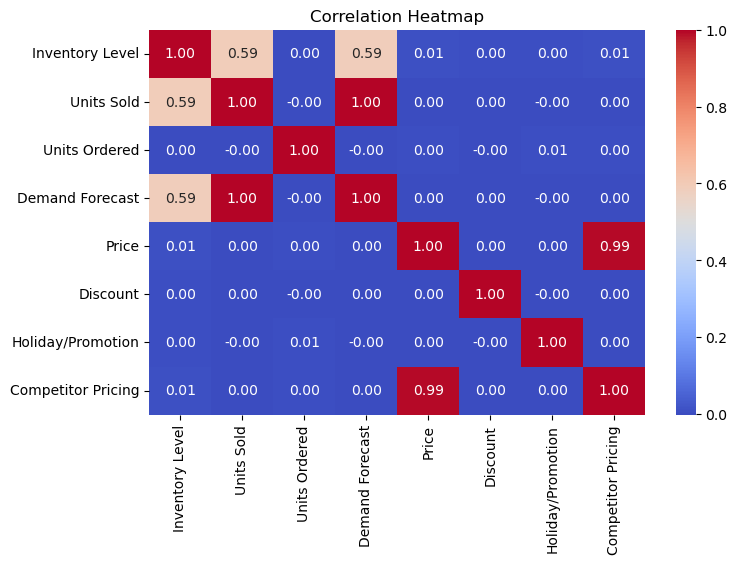

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Inventory Level, Units Sold, and Demand Forecast are moderately positively correlated (~0.59), suggesting they move together somewhat.

Price and Competitor Pricing are extremely highly correlated (0.99), meaning they almost always move together.

Units Ordered shows almost no correlation with other variables (values near 0).

Discount and Holiday/Promotion variables also show no meaningful correlation with others.

Most other variable pairs (except those mentioned above) are near zero correlation, implying independent relationships.

In [10]:
df.drop(columns=['Discount', 'Holiday/Promotion'], inplace=True)


We dropped Discount and Holiday/Promotion because they showed very low or no correlation with key outcomes like Units Sold, meaning they don't add useful predictive power and would only add noise to the model.

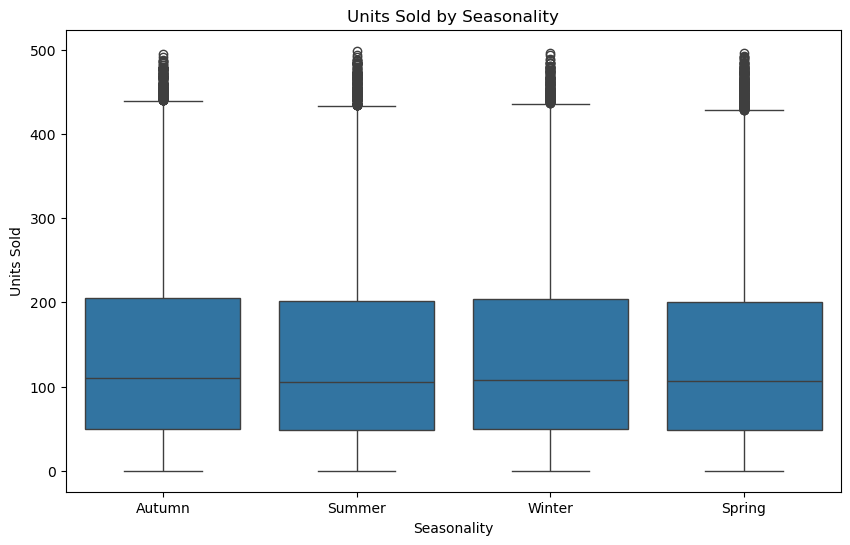

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seasonality', y='Units Sold', data=df)
plt.title('Units Sold by Seasonality')
plt.xlabel('Seasonality')
plt.ylabel('Units Sold')
plt.show()

Autumn, Summer, Winter, and Spring all have very similar distributions for Units Sold.

Medians (the center line inside each box) are almost identical across seasons.

Spreads (the boxes and whiskers) are also nearly the same, meaning variability in sales doesn't change much with seasonality.

Lots of outliers at high units sold (around 450–500), but these are similar across all seasons.

Seasonality does not have a strong effect on Units Sold in the dataset.

Selecting Variables

In [12]:

X = df[['Inventory Level', 'Demand Forecast', 'Price']].values  
y = df['Units Sold'].values


Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Standardizing

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Model

In [15]:
model = LinearRegression().fit(X_train, y_train)

In [16]:
y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

In [17]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [18]:
print("Coefficients (Slopes):", model.coef_)  
print("Intercept:", model.intercept_)
print("Training Mean Squared Error (MSE):", train_mse)
print("Training R-squared (R²):", train_r2)
print("Testing Mean Squared Error (MSE):", mse)
print("Testing R-squared (R²):", r2)

Coefficients (Slopes): [5.10480796e-01 1.08300084e+02 7.48497172e-02]
Intercept: 136.74762311901486
Training Mean Squared Error (MSE): 74.45228024473275
Training R-squared (R²): 0.993727047303825
Testing Mean Squared Error (MSE): 73.95875820335186
Testing R-squared (R²): 0.9937533062688644


Visualizations

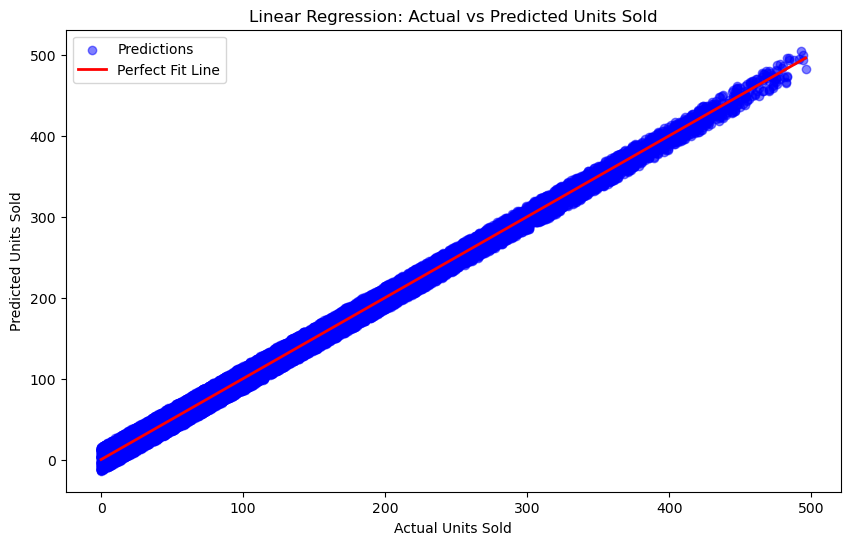

In [19]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2, label="Perfect Fit Line")
plt.title("Linear Regression: Actual vs Predicted Units Sold")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.legend()
plt.show()


Ranking

In [20]:

feature_names = ['Inventory Level', 'Demand Forecast', 'Price']


coefficients = model.coef_


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})


importance_df['Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df[['Feature', 'Coefficient']])


           Feature  Coefficient
1  Demand Forecast   108.300084
0  Inventory Level     0.510481
2            Price     0.074850


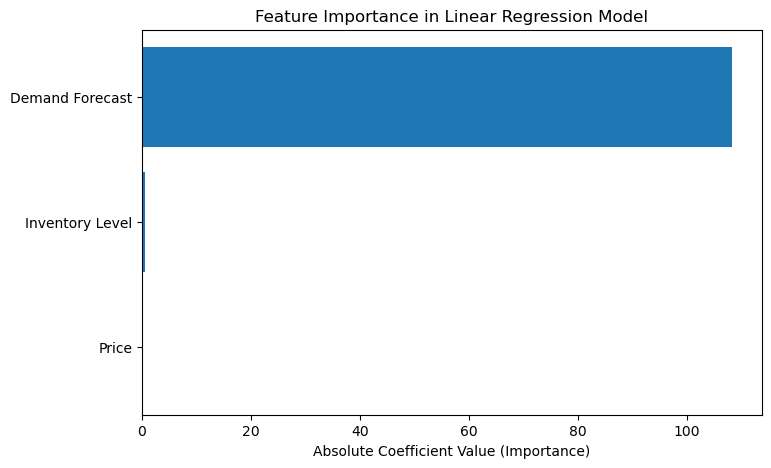

In [21]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Absolute Coefficient Value (Importance)')
plt.title('Feature Importance in Linear Regression Model')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

Cluster analysis

In [22]:
cluster_features = df[['Units Sold', 'Inventory Level', 'Price', 'Seasonality']]

In [25]:
cluster_features = pd.get_dummies(cluster_features, columns=['Seasonality'])

In [26]:
df = pd.concat([df, seasonality_dummies], axis=1)

In [27]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

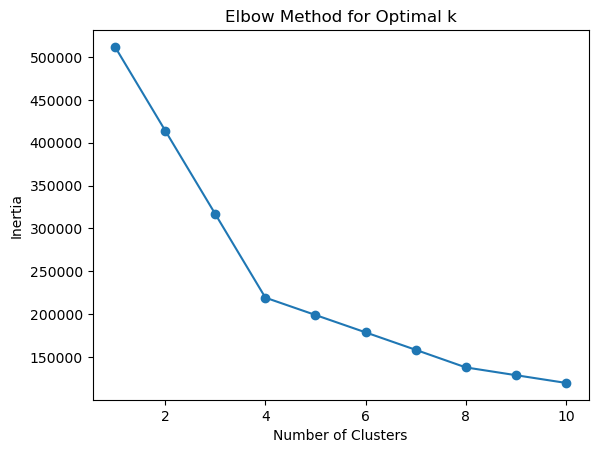

In [28]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [30]:
print(df.columns)


Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Weather Condition', 'Competitor Pricing', 'Seasonality',
       'Units Sold', 'Inventory Level', 'Price', 'Seasonality_Autumn',
       'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter',
       'Cluster'],
      dtype='object')


In [31]:
print(df['Cluster'].value_counts())

Cluster
1    18317
3    18305
2    18285
0    18193
Name: count, dtype: int64


In [32]:

df.groupby('Cluster')[['Units Sold', 'Inventory Level', 'Price']].mean()


,Units Sold,Units Sold,Inventory Level,Inventory Level,Price,Price
Cluster,,,,,,
0,137.782444,137.782444,275.424284,275.424284,54.923020,54.923020
1,135.826828,135.826828,274.740023,274.740023,55.180275,55.180275
2,136.830790,136.830790,274.651682,274.651682,55.350413,55.350413
3,135.428298,135.428298,273.069380,273.069380,55.085633,55.085633


In [33]:
seasonality_cols = [col for col in df.columns if col.startswith('Seasonality_')]
df.groupby('Cluster')[seasonality_cols].mean()

,Seasonality_Autumn,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
Cluster,,,,
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0


In [34]:
cluster_labels = {
    0: 'Autumn Products',
    1: 'Spring Products',
    2: 'Winter Products',
    3: 'Summer Products'
}

In [35]:
df['Cluster Label'] = df['Cluster'].map(cluster_labels)

In [38]:
df[['Cluster', 'Cluster Label']].head()

,Cluster,Cluster Label
0,0,Autumn Products
1,0,Autumn Products
2,3,Summer Products
3,0,Autumn Products
4,3,Summer Products
